# 02 · SED Encoding & Correlation
Ordinal encoding of survey responses, pairwise Spearman correlations,
and heatmap visualisations before and after MICE imputation.

**Encoding philosophy** (higher = more deprived):
- Income: 1 (>$200k) → 9 (<$10k)
- Education: 1 (Advanced Degree) → 8 (Never Attended)
- Housing: 1 (Own), 2 (Rent), 3 (Other Arrangement)
- Employment: 1 (Employed/Retired) → 4 (Unable to Work)
- Insurance: 1 (Yes), 2 (No)


---
### Citation

This pipeline implements the iSDI construction described in:

> **Reference:** Gupta S, Lam V, Jordan IK, Mariño-Ramírez L. *A composite socioeconomic deprivation index from All of Us survey data: associations with health outcomes and disparities.* medRxiv 2024.10.04.24314904. PMID: [39802760](https://pubmed.ncbi.nlm.nih.gov/39802760/). doi: [10.1101/2024.10.04.24314904](https://doi.org/10.1101/2024.10.04.24314904)


## 1 · Libraries

In [ ]:
library(tidyverse)
library(bigrquery)
library(reshape2)
library(tibble)
library(ggplot2)



## 2 · BQ → GCS export helper (defined once)

In [ ]:
# -----------------------------------------------------------------------
# 1. BQ → GCS export helper (define once)
# -----------------------------------------------------------------------

#' Export a BQ query result to GCS as sharded CSVs, then read back into R.
#'
#' @param concept_id  Integer OMOP concept_id for the survey question
#' @param tag         Short string used to name the GCS subdirectory
#' @return tibble with columns: person_id, question, answer
bq_pull_survey <- function(concept_id, tag) {

  sql <- paste0(
    "SELECT answer.person_id, answer.question, answer.answer
     FROM `ds_survey` answer
     WHERE question_concept_id IN (", concept_id, ")"
  )

  export_path <- file.path(
    Sys.getenv("WORKSPACE_BUCKET"),
    "bq_exports",
    Sys.getenv("OWNER_EMAIL"),
    strftime(lubridate::now(), "%Y%m%d"),
    tag,
    paste0(tag, "_*.csv")
  )
  message(sprintf("[%s] Exporting to %s", tag, export_path))

  bq_table_save(
    bq_dataset_query(
      Sys.getenv("WORKSPACE_CDR"), sql,
      billing = Sys.getenv("GOOGLE_PROJECT")
    ),
    export_path,
    destination_format = "CSV"
  )

  # BUG FIX #2: actual columns are person_id / question / answer, not "survey"
  col_types <- cols(
    person_id = col_double(),
    question  = col_character(),
    answer    = col_character()
  )

  csv_files <- system2("gsutil", args = c("ls", export_path),
                       stdout = TRUE, stderr = TRUE)
  bind_rows(lapply(csv_files, function(csv) {
    message(sprintf("  Loading %s", csv))
    read_csv(pipe(sprintf("gsutil cat %s", csv)),
             col_types = col_types, show_col_types = FALSE)
  }))
}



## 3 · Pull data

In [ ]:
# -----------------------------------------------------------------------
# 2. Pull data
# -----------------------------------------------------------------------

edu_df <- bq_pull_survey(1585940, "survey_edu")
emp_df <- bq_pull_survey(1585952, "survey_emp")
inc_df <- bq_pull_survey(1585375, "survey_inc")
ins_df <- bq_pull_survey(1585386, "survey_ins")
own_df <- bq_pull_survey(1585370, "survey_own")

# Sanity check
cat("Row counts:\n")
cat(sprintf("  edu: %d\n", nrow(edu_df)))
cat(sprintf("  emp: %d\n", nrow(emp_df)))
cat(sprintf("  inc: %d\n", nrow(inc_df)))
cat(sprintf("  ins: %d\n", nrow(ins_df)))
cat(sprintf("  own: %d\n", nrow(own_df)))



## 4 · Ordinal encoding

In [ ]:
# -----------------------------------------------------------------------
# 3. Ordinal encoding
# -----------------------------------------------------------------------

# --- Income (9 levels; higher = more deprived) ---
encoded_inc_df <- inc_df %>%
  mutate(ord_answer = case_when(
    answer == "Annual Income: more 200k"  ~ "1",
    answer == "Annual Income: 150k 200k"  ~ "2",
    answer == "Annual Income: 100k 150k"  ~ "3",
    answer == "Annual Income: 75k 100k"   ~ "4",
    answer == "Annual Income: 50k 75k"    ~ "5",
    answer == "Annual Income: 35k 50k"    ~ "6",
    answer == "Annual Income: 25k 35k"    ~ "7",
    answer == "Annual Income: 10k 25k"    ~ "8",
    answer == "Annual Income: less 10k"   ~ "9",
    answer %in% c("PMI: Skip", "PMI: Prefer Not To Answer") ~ NA_character_
  )) %>%
  select(person_id, ord_answer_inc = ord_answer)

# --- Education (8 levels; higher = more deprived) ---
encoded_edu_df <- edu_df %>%
  mutate(ord_answer = case_when(
    answer == "Highest Grade: Advanced Degree"      ~ "1",
    answer == "Highest Grade: College Graduate"     ~ "2",
    answer == "Highest Grade: College One to Three" ~ "3",
    answer == "Highest Grade: Twelve Or GED"        ~ "4",
    answer == "Highest Grade: Nine Through Eleven"  ~ "5",
    answer == "Highest Grade: Five Through Eight"   ~ "6",
    answer == "Highest Grade: One Through Four"     ~ "7",
    answer == "Highest Grade: Never Attended"       ~ "8",
    answer %in% c("PMI: Skip", "PMI: Prefer Not To Answer") ~ NA_character_
  )) %>%
  select(person_id, ord_answer_edu = ord_answer)

# --- Housing (3 levels; higher = more deprived) ---
encoded_own_df <- own_df %>%
  mutate(ord_answer = case_when(
    answer == "Current Home Own: Own"              ~ "1",
    answer == "Current Home Own: Rent"             ~ "2",
    answer == "Current Home Own: Other Arrangement"~ "3",
    answer %in% c("PMI: Prefer Not To Answer", "PMI: Dont Know") ~ NA_character_,
    answer == "PMI: Skip"                          ~ NA_character_
  )) %>%
  select(person_id, ord_answer_own = ord_answer)

# --- Employment (4 levels; higher = more deprived) ---
# Encoding order 4 (final chosen version):
#   1 = Employed For Wages / Retired
#   2 = Self Employed
#   3 = Out of Work < 1yr
#   4 = Out of Work ≥ 1yr / Student / Unable to Work
#
# BUG FIX #5: original arrange(ord_answer, desc(ord_answer)) is contradictory
# and silently keeps the LOWEST value. Corrected: arrange(desc(ord_answer))
# to retain the most deprived (highest) value per person with multiple responses.
encoded_emp_df <- emp_df %>%
  mutate(ord_answer = case_when(
    answer == "Employment Status: Employed For Wages"       ~ "1",
    answer == "Employment Status: Retired"                 ~ "1",
    answer == "Employment Status: Self Employed"           ~ "2",
    answer == "Employment Status: Out Of Work Less Than One" ~ "3",
    answer == "Employment Status: Out Of Work One Or More" ~ "4",
    answer == "Employment Status: Unable To Work"          ~ "4",
    answer == "Employment Status: Student"                 ~ "4",
    answer == "Employment Status: Homemaker"               ~ NA_character_,
    answer %in% c("PMI: Skip", "PMI: Prefer Not To Answer") ~ NA_character_
  )) %>%
  select(person_id, ord_answer) %>%
  arrange(desc(ord_answer)) %>%              # keep most deprived per person
  distinct(person_id, .keep_all = TRUE) %>%
  rename(ord_answer_emp = ord_answer)

# --- Insurance (2 levels; higher = more deprived) ---
encoded_ins_df <- ins_df %>%
  mutate(ord_answer = case_when(
    answer == "Health Insurance: Yes"              ~ "1",
    answer == "Health Insurance: No"               ~ "2",
    answer == "PMI: Dont Know"                     ~ NA_character_,
    answer %in% c("PMI: Skip", "PMI: Prefer Not To Answer") ~ NA_character_
  )) %>%
  select(person_id, ord_answer_ins = ord_answer)

# -----------------------------------------------------------------------


## 5 · Merge all five domains

In [ ]:
# 4. Merge all five domains
# -----------------------------------------------------------------------

df <- Reduce(
  function(x, y) merge(x, y, by = "person_id", all = TRUE),
  list(encoded_inc_df, encoded_edu_df, encoded_own_df,
       encoded_ins_df, encoded_emp_df)
)

# Convert string encodings to numeric (NA strings already NA_character_)
df <- df %>%
  mutate(across(-person_id, as.numeric))

cat(sprintf("\nMerged df: %d rows x %d cols\n", nrow(df), ncol(df)))
cat("Missing values per column:\n")
print(colSums(is.na(df)))

# -----------------------------------------------------------------------


## 6 · Spearman correlation matrix (pre-imputation)

In [ ]:
# 5. Correlation matrix (pre-imputation)
# -----------------------------------------------------------------------

cor_vars <- c("ord_answer_emp", "ord_answer_inc", "ord_answer_edu",
              "ord_answer_own", "ord_answer_ins")
cor_labels <- c("Employment", "Income", "Education", "Housing", "Insurance")

correlation_matrix <- cor(
  df[, cor_vars],
  method = "spearman",
  use   = "pairwise.complete.obs"
)
colnames(correlation_matrix) <- cor_labels
rownames(correlation_matrix) <- cor_labels
print(round(correlation_matrix, 3))

# -----------------------------------------------------------------------


## 7 · Heatmap — pre-imputation

*(Example output shown below)*

In [ ]:
# 6. Heatmap — pre-imputation
# -----------------------------------------------------------------------

# BUG FIX #3: original tibble() used <- inside function args; replaced with =
make_cor_heatmap <- function(cor_mat, title, outfile) {
  # BUG FIX #4: build cor_df BEFORE calling ggplot on it
  cor_df <- tibble(
    col1        = rep(rownames(cor_mat), times = ncol(cor_mat)),
    col2        = rep(colnames(cor_mat), each  = nrow(cor_mat)),
    Correlation = as.vector(cor_mat)
  )

  p <- ggplot(cor_df, aes(x = col1, y = col2, fill = Correlation)) +
    geom_tile(color = "white", linewidth = 1) +
    geom_text(aes(label = round(Correlation, 2)), color = "white", size = 4) +
    scale_fill_gradient(low = "#2166AC", high = "#D6604D", limits = c(0, 1)) +
    labs(title = title) +
    theme_classic() +
    theme(
      axis.title.x  = element_blank(),
      axis.title.y  = element_blank(),
      axis.text.x   = element_text(size = 11, angle = 45, hjust = 1),
      axis.text.y   = element_text(size = 11)
    )

  ggsave(outfile, plot = p, width = 6.67, height = 6.67)
  message(sprintf("Saved %s", outfile))
  invisible(p)
}

make_cor_heatmap(
  correlation_matrix,
  title   = "SED Correlation (pre-imputation)",
  outfile = "results/correlation_before_imputation.pdf"
)

# -----------------------------------------------------------------------


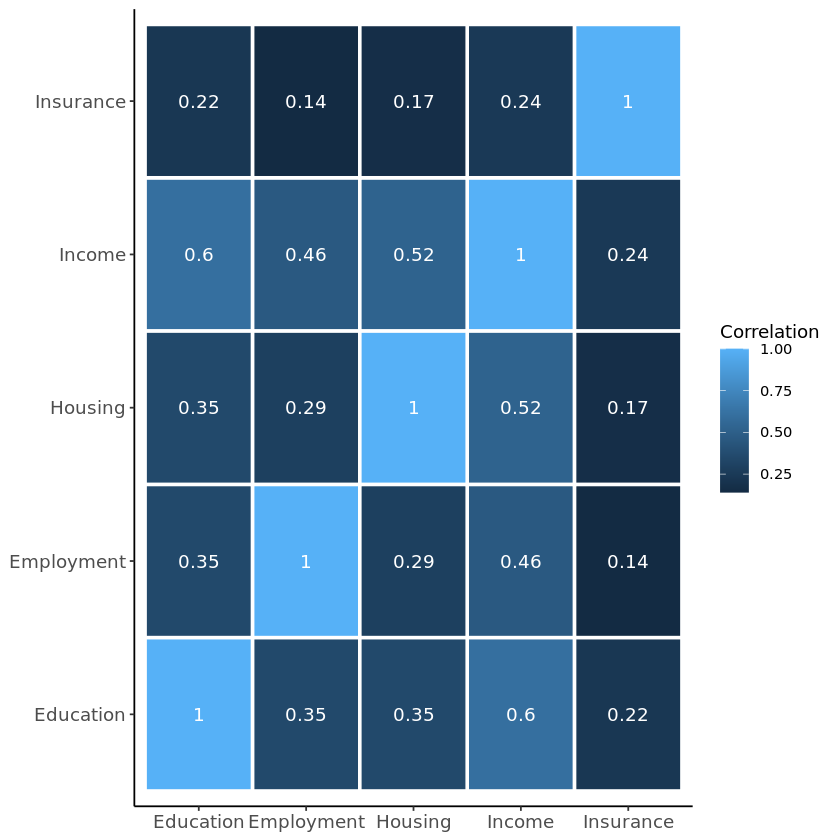
*Pre-imputation Spearman correlation heatmap*

## 8 · Heatmap — post-imputation

*(Example output shown below)*

In [ ]:
# 7. Post-imputation correlation (reads from pre-existing imputed file)
# -----------------------------------------------------------------------

imputed_path <- "/home/jupyter/imputed_ds3_trial2.tsv"

if (file.exists(imputed_path)) {
  df_imp <- read_csv(imputed_path, show_col_types = FALSE)

  imp_vars   <- c("Income", "Education", "Housing", "Employment", "Insurance")
  cor_imp    <- cor(df_imp[, imp_vars], method = "spearman",
                    use = "pairwise.complete.obs")

  make_cor_heatmap(
    cor_imp,
    title   = "SED Correlation (post-imputation)",
    outfile = "results/correlation_after_imputation.pdf"
  )
} else {
  message(sprintf("Imputed file not found at %s; skipping post-imputation plot.", imputed_path))
}


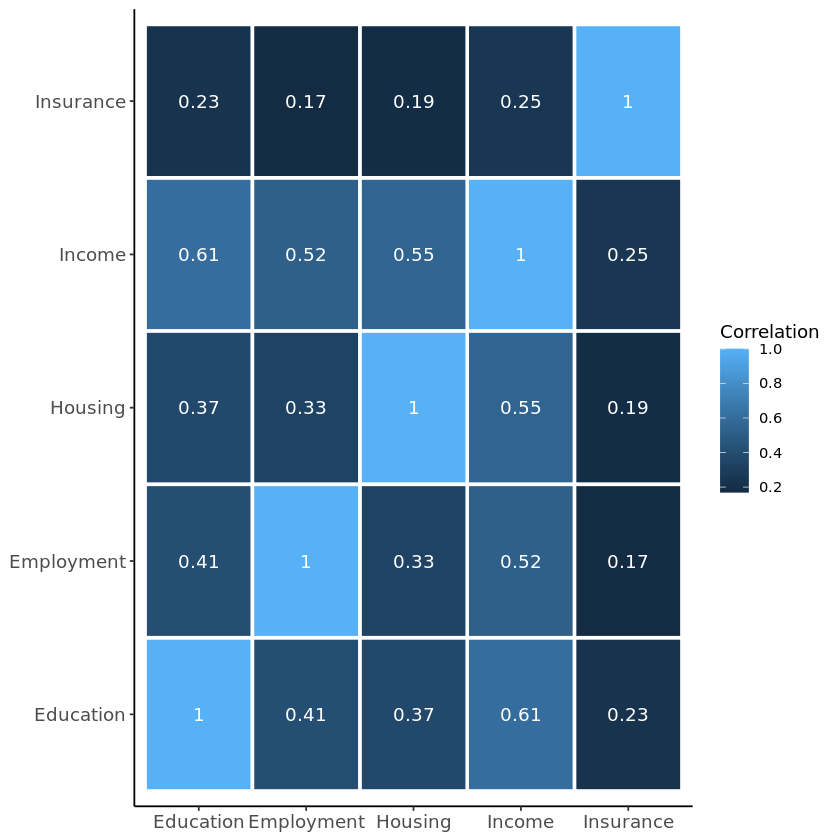
*Post-imputation Spearman correlation heatmap (MICE chain 3)*

> **Interpretation:** MICE modestly increases all pairwise correlations
> (e.g. Employment–Income: 0.46 → 0.52) because the ordinal regression
> imputation model uses the other SED variables as predictors — expected
> behaviour, not an artefact.
